In [1]:
from google.colab import userdata
github_token = userdata.get("GITHUB_TOKEN")

!git config --global user.email "roshinsthomas@gmail.com"
!git config --global user.name 'roshinsthomas'

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

#load datasets
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


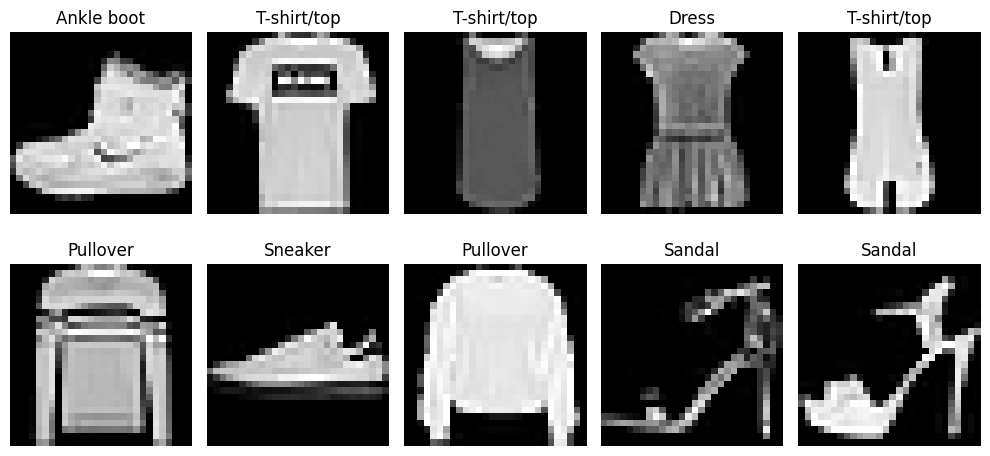

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5, i +1)
  plt.imshow(x_train[i], cmap = 'gray')
  plt.title(class_names[y_train[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Check the number and dimensions of images and labels
print("X Train:", np.unique(y_train))
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

# Inspect how pixel values are stored
print("Pixel data type:", x_train.dtype)
print("Pixel range:", x_train.min(), "to", x_train.max())

X Train: [0 1 2 3 4 5 6 7 8 9]
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel data type: uint8
Pixel range: 0 to 255


In [5]:
# Find each category number and count its occurrences
labels, counts = np.unique(y_train, return_counts=True)

for label, count in zip(labels, counts):
    print(f"{label}: {class_names[label]} — {count} images")

0: T-shirt/top — 6000 images
1: Trouser — 6000 images
2: Pullover — 6000 images
3: Dress — 6000 images
4: Coat — 6000 images
5: Sandal — 6000 images
6: Shirt — 6000 images
7: Sneaker — 6000 images
8: Bag — 6000 images
9: Ankle boot — 6000 images


In [6]:
#checking for missing data
print("Missing data in x_train:",np.isnan(x_train).sum())
print("Missing data in y_train:",np.isnan(y_train).sum())
print("Missing data in x_test:",np.isnan(x_test).sum())
print("Missing data in y_test:",np.isnan(y_test).sum())

Missing data in x_train: 0
Missing data in y_train: 0
Missing data in x_test: 0
Missing data in y_test: 0


In [7]:
#Normalising the pixel values from 0 - 255 to 0 - 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [8]:
#checking the pixel range
print("Pixel range of x_train :",x_train.min(),'to',x_train.max() )
print("Pixel range of x_test :",x_test.min(),'to',x_test.max() )
print("Pixel data type :",x_train.dtype)

Pixel range of x_train : 0.0 to 1.0
Pixel range of x_test : 0.0 to 1.0
Pixel data type : float32


In [9]:
#Convert the shape to (number of images, height, width, channels)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:",x_train.shape)
print("Test shape:",x_test.shape)

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [10]:
from sklearn.model_selection import train_test_split

x_train_fit, x_val, y_train_fit, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state = 42,
    stratify=y_train
    )

print("Training :",x_train_fit.shape,y_train_fit.shape)
print("Validation :",x_val.shape,y_val.shape)

Training : (48000, 28, 28, 1) (48000,)
Validation : (12000, 28, 28, 1) (12000,)


In [11]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [12]:
#since the validation loss is increasing after the epoch 7
#we are going to implement early stopping
from keras.callbacks import EarlyStopping

#keep the weights from the epoch with the lowest validation loss
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 2,
    restore_best_weights = True
)

In [13]:
model = Sequential([
    Input(shape = (28,28,1)),

    #Learn 32 filters that detect patterns in the images
    #First convolutional layer
    Conv2D(filters = 32, padding='same',
           kernel_size = (3,3), activation = 'relu'),

    #Reduce each feature map to half
    MaxPooling2D(pool_size = (2,2)),

    # Second convolutional layer
    Conv2D(
        filters = 64, kernel_size = (3, 3),
        activation = 'relu', padding = 'same'
    ),

    #second max pooling layer
    MaxPooling2D(pool_size=(2,2)),

    # Arrange each images feature values into one vector
    Flatten(),

    #combine the extracted features using 128 neurons
    Dense(128, activation = 'relu'),

    #to avoid overfitting, we add a dropout layer
    #randomly drop 30% of the incoming values during trainings
    Dropout(0.3),

    #output layer
    Dense(10, activation = 'softmax')

])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    x_train_fit,
    y_train_fit,
    epochs = 20,
    batch_size = 32,
    validation_data = (x_val,y_val),
    callbacks = [early_stopping]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8242 - loss: 0.4838 - val_accuracy: 0.8932 - val_loss: 0.3022
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 40ms/step - accuracy: 0.8851 - loss: 0.3131 - val_accuracy: 0.9033 - val_loss: 0.2597
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9016 - loss: 0.2681 - val_accuracy: 0.9151 - val_loss: 0.2318
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.9125 - loss: 0.2350 - val_accuracy: 0.9174 - val_loss: 0.2286
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9219 - loss: 0.2109 - val_accuracy: 0.9117 - val_loss: 0.2384
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9274 - loss: 0.1953 - val_accuracy: 0.9193 - val_loss: 0.2250
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9346 - loss: 0.1743 - val_accuracy: 0.9181 - val_loss: 0.2289
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 25ms/step - accuracy: 0.9392 -

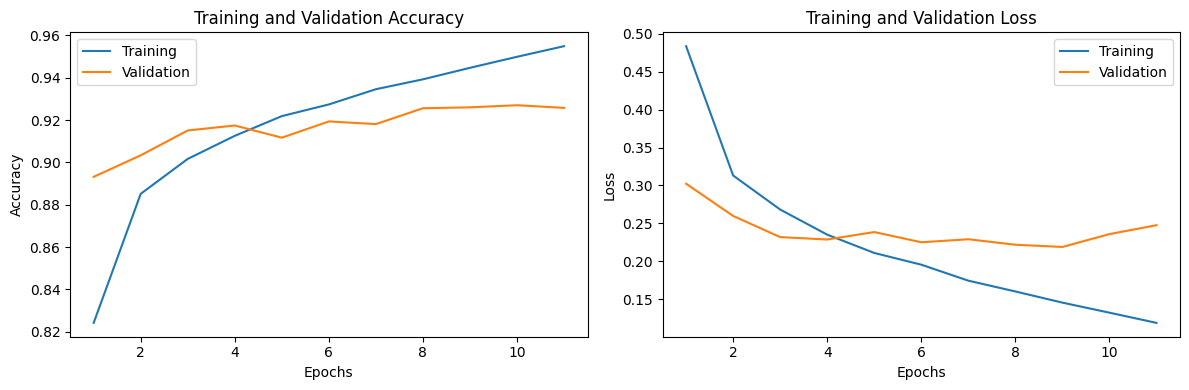

In [15]:
#To check the accuracy

epochs = range(1, len(history.history['loss']) + 1 )

plt.figure(figsize=(12,4))

#compare training and validation accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history.history['accuracy'], label = "Training")
plt.plot(epochs, history.history['val_accuracy'], label = "Validation")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#compare training and validation loss
plt.subplot(1,2,2)
plt.plot(epochs, history.history['loss'], label = "Training")
plt.plot(epochs, history.history['val_loss'], label = "Validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
#Evaluate on the held out test set without updating weights
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 0)

print(f"Test loss :{test_loss:.2f}")
print(f"Test Accuraacy : {test_acc * 100:.2f}")

Test loss :0.24
Test Accuraacy : 91.50


Predicted category: Sneaker
Actual category: Sneaker


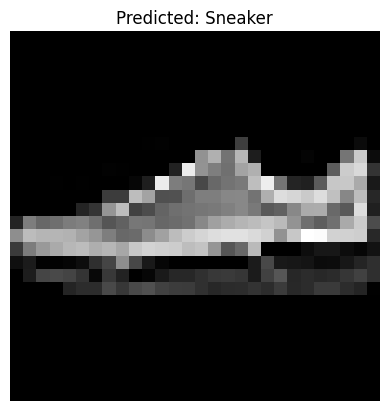

In [17]:
import numpy as np

# Keep the batch dimension: shape (1, 28, 28, 1)
probabilities = model.predict(x_test[9:10], verbose=0)

# Select the category with the highest probability
predicted_label = np.argmax(probabilities[0])

print("Predicted category:", class_names[predicted_label])
print("Actual category:", class_names[y_test[9]])

plt.imshow(x_test[9, :, :, 0], cmap="gray")
plt.title("Predicted: " + class_names[predicted_label])
plt.axis("off")
plt.show()

In [18]:
# Get 10 category probabilities for each test image
test_probabilities = model.predict(x_test, verbose=0)

# Pick the category with the highest probability for each image
y_pred = np.argmax(test_probabilities, axis=1)

print("Probability array shape:", test_probabilities.shape)
print("Predicted labels shape:", y_pred.shape)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

Probability array shape: (10000, 10)
Predicted labels shape: (10000,)
First 10 predictions: [9 2 1 1 6 1 4 6 5 7]
First 10 actual labels: [9 2 1 1 6 1 4 6 5 7]


In [19]:
#get 10 category probablities for each test image
test_probabilities = model.predict(x_test,verbose=0)

#pick the category with the highest probabilitiy for each image
y_pred = np.argmax(test_probabilities, axis  = 1)

print("Probability array shape:",test_probabilities.shape)
print("Predicted labels shape:",y_pred.shape)

print("first 10 predictions:",y_pred[:10])
print("first 10 actual labels:",y_test[:10])

Probability array shape: (10000, 10)
Predicted labels shape: (10000,)
first 10 predictions: [9 2 1 1 6 1 4 6 5 7]
first 10 actual labels: [9 2 1 1 6 1 4 6 5 7]


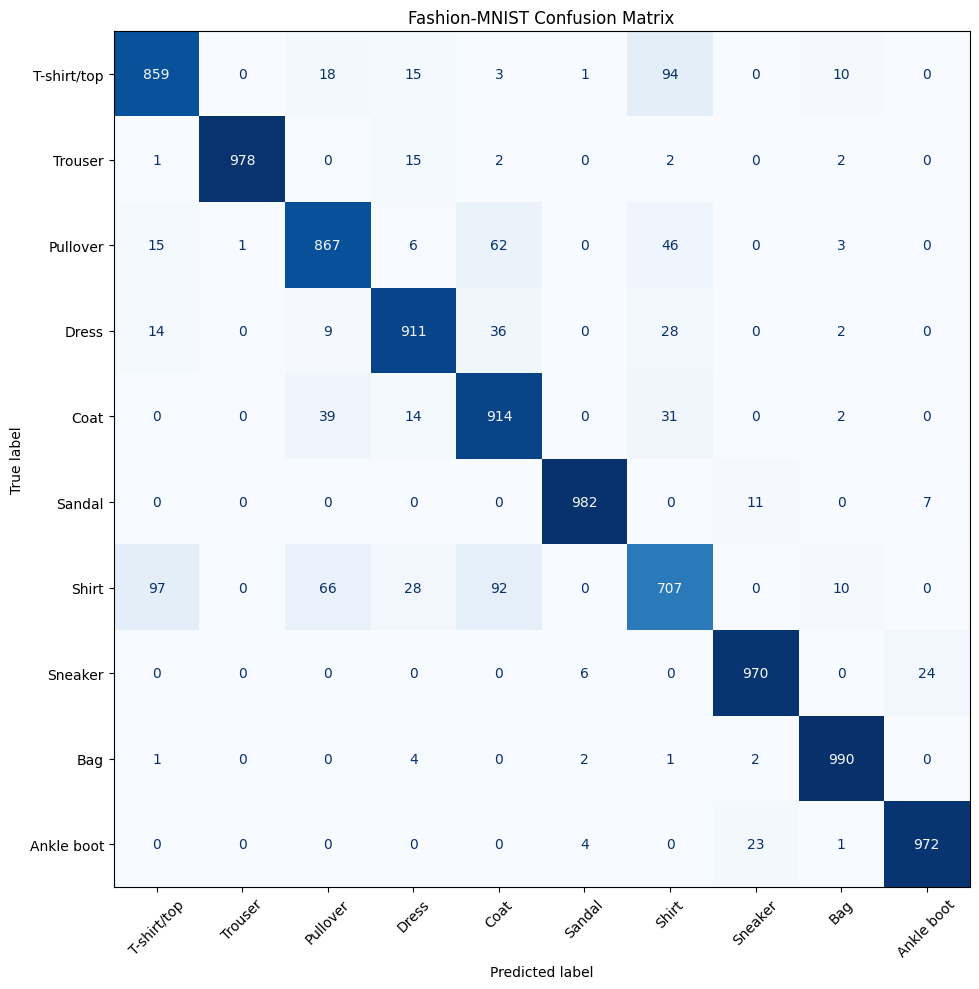

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#compare the actual labels with predicted labels
cm = confusion_matrix(y_test, y_pred, labels = range(10))

fig, ax = plt.subplots(figsize=(10,10))

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = class_names
)

display.plot(
    ax = ax, cmap = 'Blues',
    values_format = "d",
    xticks_rotation = 45,
    colorbar = False
)

plt.title("Fashion-MNIST Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report

#show performance for each category
print(classification_report(
    y_test,
    y_pred,
    labels = range(10),
    target_names = class_names,
    digits = 3,
    zero_division = 0
))

              precision    recall  f1-score   support

 T-shirt/top      0.870     0.859     0.865      1000
     Trouser      0.999     0.978     0.988      1000
    Pullover      0.868     0.867     0.867      1000
       Dress      0.917     0.911     0.914      1000
        Coat      0.824     0.914     0.867      1000
      Sandal      0.987     0.982     0.984      1000
       Shirt      0.778     0.707     0.741      1000
     Sneaker      0.964     0.970     0.967      1000
         Bag      0.971     0.990     0.980      1000
  Ankle boot      0.969     0.972     0.971      1000

    accuracy                          0.915     10000
   macro avg      0.915     0.915     0.914     10000
weighted avg      0.915     0.915     0.914     10000



In [27]:
#save the architecture, learned weights, and optimizer state
model.save("fashion_mnist_cnn.keras")
model.save_weights("fashion_mnist.weights.h5")

In [32]:
#checking whether the model can be loaded
from tensorflow.keras.models import load_model

#load the model
loaded_model = load_model(
    "/content/drive/MyDrive/Projects/CNN_Fashion_MNIST/fashion_mnist_cnn.keras")

In [33]:
#compare the loaded model and existing model with
#the first 10 images in the dataset
original_pred = model.predict(x_test[:10], verbose = 10)
loaded_model_pred = loaded_model.predict(x_test[:10],verbose = 0)

print(
    "Prediction Match:",
    np.allclose(original_pred, loaded_model_pred)
)

Prediction Match: True
